# Odor preference

**Dr. Panagiotis Sakagiannis, Dr. Alexandros Marantis**

## About this notebook

The two previous assays followed individual animals. This one does not : it is a **group assay**,
the workhorse of larval learning research, and its entire output is a single number.

The setup is simple. A circular dish, one odor on the left, another on the right, a population
released in the middle, and a few minutes to make up their minds. At the end you count how many
animals are on each side and compute the **preference index**. Nothing about individual trajectories
enters the result - which is precisely why the assay scales to the hundreds of animals that learning
experiments require.

The stored `PItest_off` experiment sets this up with a model whose two odor gains are fixed, so what
it measures is **innate** preference. The `off` in its name means *off food* : the test is run on a
plain substrate, as in the standard protocol.

**What you will be able to do afterwards**

- Run a group assay and read its population-level result.
- Say exactly how the preference index is defined, and where the implementation differs from the
  textbook formula.
- Connect the single number back to the trajectories that produced it.

**Prerequisites** : [Chemotaxis](chemotaxis.ipynb). The sensing mechanism is the same; here there
are two odors instead of one.

**Cost** : one simulation of a couple of minutes. This experiment computes only the preference
index, so there is no expensive post-processing.

**Switches in this notebook**

| switch | default | what it turns on |
|---|---|---|
| `RUN_SIMULATION` | `True` | the experiment itself, and therefore every result below |
| `SAVE_VIDEO` | `False` | a second run that renders the dish to a video file |

## Setup

In [1]:
%matplotlib inline

import larvaworld
from larvaworld.lib import reg
from larvaworld.lib.sim.single_run import ExpRun
import numpy as np

larvaworld.VERBOSE = 1

# Tutorial safety switches
RUN_SIMULATION = True  # the point of this notebook; a few minutes of compute
SAVE_VIDEO = False  # re-run with rendering and write a video file

EXPERIMENT = "PItest_off"
N = 20  # larvae; the stored experiment's duration and timestep are left untouched

MEDIA_DIR = "./media/simulated_experiments"
plot_dir = f"{MEDIA_DIR}/{EXPERIMENT}"

Initializing larvaworld registry


Registry configured!


## Section 1 : The experiment

Two odor sources, 80 mm apart in a 100 mm dish, each with its own identity : `CS` on the left and
`UCS` on the right. In a learning experiment the CS is the odor that was paired with a reward during
training; here nothing was trained, so the two are simply two different smells.

In [2]:
conf = reg.conf.Exp.getID(EXPERIMENT)
env = conf.env_params

print(f"Experiment : {EXPERIMENT}")
print(f"  duration : {conf.duration} min   timestep : {conf.dt} s")
print(
    f"  arena    : {env.arena.geometry}, {[round(x * 1000) for x in env.arena.dims]} mm"
)

sources = env.food_params.source_units
if sources:
    print("  odor sources :")
    for sid, s in sources.items():
        pos_mm = [round(v * 1000, 1) for v in s.pos]
        print(
            f"     {sid:5s} at {pos_mm} mm, odor {s.odor.id!r} "
            f"(intensity {s.odor.intensity}, spread {s.odor.spread:.3f})"
        )
    print(f"  odorscape : {env.odorscape.odorscape}")
else:
    print("  odor sources : none")

for gid, g in conf.larva_groups.items():
    dis = g.distribution
    print(
        f"  larva group {gid!r} : model {g.model if isinstance(g.model, str) else '(inline)'}, "
        f"N={dis.N} placed {dis.mode} around {[round(v * 1000) for v in dis.loc]} mm"
    )

Experiment : PItest_off
  duration : 5.0 min   timestep : 0.1 s
  arena    : circular, [100, 100] mm
  odor sources :
     CS    at [-40.0, 0.0] mm, odor 'CS' (intensity 2.0, spread 0.010)
     UCS   at [40.0, 0.0] mm, odor 'UCS' (intensity 2.0, spread 0.010)
  odorscape : Gaussian
  larva group 'navigator_x2' : model navigator_x2, N=30 placed uniform around [0, 0] mm


The model is `navigator_x2` - a navigator with **two** olfactor gains rather than one, so it can
respond differently to the two odors. Those gains are what a preference test measures, and what a
learning experiment would change.

In [3]:
olf = reg.conf.Model.getID("navigator_x2").brain.olfactor
print("Olfactor of the 'navigator_x2' model :")
print(f"  mode  : {olf.mode}")
print(f"  gains : {olf.gain_dict}")

Olfactor of the 'navigator_x2' model :
  mode  : default
  gains : {'CS': 150.0, 'UCS': 0.0}


The experiment's enrichment is a single entry, `PI`. Nothing else is computed after the run - no
kinematics, no bout annotation - because none of it enters the result.

In [4]:
print("Metrics computed after the run :", conf.enrichment.proc_keys)

Metrics computed after the run : ['PI']


## Section 2 : Running it

In [5]:
d = None
if RUN_SIMULATION:
    r = ExpRun(experiment=EXPERIMENT, N=N)
    r.simulate()
    d = r.datasets[0]
    print(f"{d.id} : {d.config.N} larvae, stored at {d.dir}")
else:
    print("Set RUN_SIMULATION = True to run the experiment.")

--- Simulation PItest_off_9 initialized!--- 
--- Simulation PItest_off_9 : Generating agent groups!--- 



Run time: 0:01:09.644350
Simulation finished
--- Simulation PItest_off_9 completed in 70 seconds!--- 
--- Enriching dataset navigator_x2 ---
--- Dataset navigator_x2 enriched ---
--------------------------------


***** Dataset navigator_x2 stored.-----
Simulation PItest_off_9 stored in directory C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SimGroup/exp_runs/PItest_off/PItest_off_9
navigator_x2 : 20 larvae, stored at C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SimGroup/exp_runs/PItest_off/PItest_off_9/data/navigator_x2


In [6]:
if SAVE_VIDEO:
    r_vid = ExpRun(
        experiment=EXPERIMENT,
        N=N,
        screen_kws={
            "vis_mode": "video",
            "show_display": False,
            "save_video": True,
            "media_dir": MEDIA_DIR,
            "video_file": "odor_preference",
            "visible_trails": True,
        },
    )
    r_vid.simulate()
    print(f"Video written to {MEDIA_DIR}/odor_preference.mp4")
else:
    print("Set SAVE_VIDEO = True to render this experiment to a video file.")

Set SAVE_VIDEO = True to render this experiment to a video file.


## Section 3 : The result

The preference index is attached to the dataset's configuration, because it is a property of the
population rather than of any animal.

In [7]:
if d is not None:
    PI = d.config.PI
    print(f"Preference index : {PI['PI']:+.3f}   (scored larvae : {PI['N']})")

    PI2 = d.config.PI2
    if PI2 is not None and not np.isnan(PI2):
        print(f"Trajectory-based index : {PI2:+.3f}")

Preference index : +0.800   (scored larvae : 20)


Do not be surprised if the index comes out at or near **+1**. The stored `navigator_x2` model has
gains of 150 for the `CS` odor and 0 for the `UCS` one - one odor is strongly attractive and the
other is not an odor as far as the animal is concerned. The assay therefore has an easy answer, and
this run sits at a corner of the preference landscape rather than somewhere informative in its
middle. A real experiment compares *conditions*, and the interesting version of this simulation is
the gain sweep described at the end of this notebook.

`ExpRun.analyze()` is the analysis of this experiment, and for a preference test it is deliberately
not a set of figures : it collects the index for every group of the run and stores it in
`r.results`. That is what a batch of such experiments consumes.

In [8]:
if d is not None:
    r.analyze()
    print(r.results)

{'PIs': {'navigator_x2': 0.8}, 'PI2s': {'navigator_x2': nan}}


### How the index is defined

A positive index means a preference for the **left** odor, negative for the right, and zero means no
preference.

The textbook definition counts the two halves of the dish :

$$PI = \frac{N_l - N_r}{N}$$

Larvaworld's `LarvaDataset.comp_PI` is slightly stricter, and deliberately so : it scores only the
animals that ended up **outside a central neutral band**, of width `0.2 x arena_xdim` - 20 mm in a
100 mm dish. An animal that never committed to either side does not count as evidence for either.
This is the convention of the standard assay, and it is worth knowing when comparing a number
produced here with one from a paper.

`PI2` is a different, complementary measure : rather than looking at final positions, it averages
each larva's relative distance to the two sources over the *whole* run. It reports a preference
expressed throughout the experiment rather than at its end, and it is `nan` when the trajectory
columns it needs were not computed.

In [9]:
if d is not None:
    x_dim = d.config.env_params.arena.dims[0]
    band = 0.2 * x_dim
    xs = (
        d.e["x"].values
        if "x" in d.e.columns
        else d.s["x"].dropna().groupby("AgentID").last().values
    )
    N_l = int((xs <= -band / 2).sum())
    N_r = int((xs >= +band / 2).sum())
    N_m = len(xs) - N_l - N_r
    print(f"arena width      : {x_dim * 1000:.0f} mm")
    print(f"neutral band     : {band * 1000:.0f} mm wide, centred")
    print(f"left / right / undecided : {N_l} / {N_r} / {N_m}")
    print(f"PI = ({N_l} - {N_r}) / {len(xs)} = {(N_l - N_r) / len(xs):+.3f}")

arena width      : 100 mm
neutral band     : 20 mm wide, centred
left / right / undecided : 16 / 0 / 4
PI = (16 - 0) / 20 = +0.800


## Section 4 : The behavior behind the number

A group assay throws away the trajectories, but the simulation kept them. The two figures below are
not part of this experiment's registered analysis - a preference test reports a number, not plots -
but they show the split that the index summarizes.

Plot comparative_trajectories_default.pdf saved as ./media/simulated_experiments/PItest_off\comparative_trajectories_default.pdf


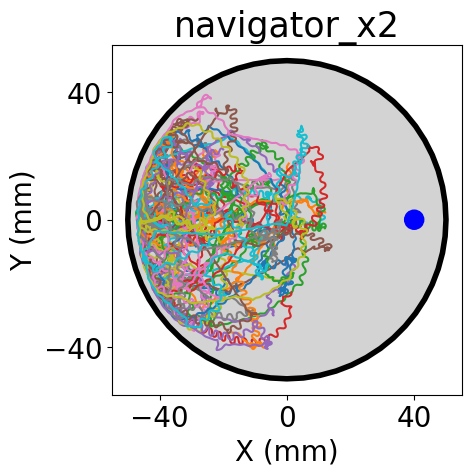

In [10]:
plot_kws = {
    "datasets": [d] if d is not None else [],
    "save_to": plot_dir,
    "show": False,
    "subfolder": None,
}

if d is not None:
    display(reg.graphs.run("trajectories", **plot_kws))

And the distribution of final x positions - the raw material of the index. A population with no
preference is centred on zero; a preference shows as a shift towards one source.

Plot final_x_position.pdf saved as ./media/simulated_experiments/PItest_off\final_x_position.pdf


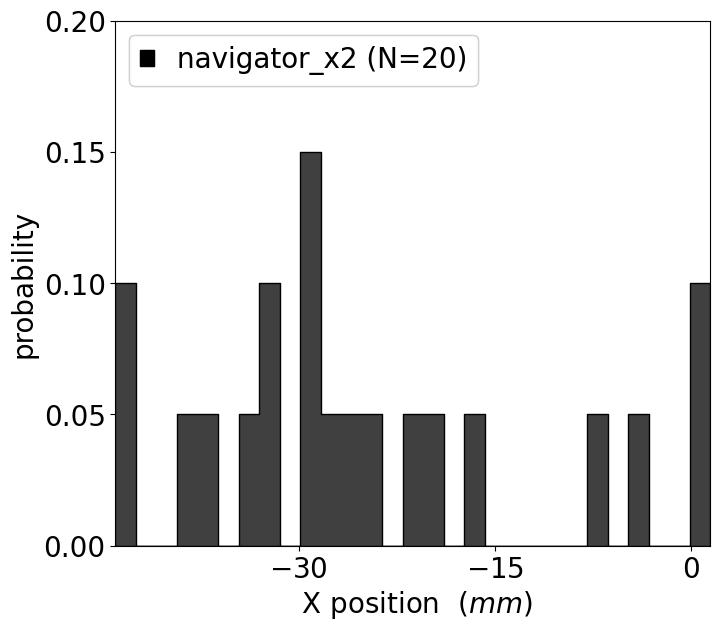

In [11]:
if d is not None:
    display(
        reg.graphs.run("endpoint hist", name="final_x_position", ks=["x"], **plot_kws)
    )

## What the paper reports

This assay is the *Odor preference test* of Sakagiannis et al. (2025), which follows the standard
protocol of the Maggot Learning Manual (Michels et al., 2017).

**Innate preference is a landscape, not a number.** Because the turning modulation depends on an
odor-specific gain, the paper first mapped the behavioral operating range : a sweep over 25 x 25
combinations of left and right odor gains, 30 larvae each, producing the preference-index landscape
of its Figure 6A. The single run above is one point in that landscape - the point where the two
gains are the ones stored in `navigator_x2`.

**Learned preference is the point of the assay.** In the paper's Figure 6B-D the gain is not fixed
but *derived*: a spiking mushroom-body model (Jürgensen et al., 2024) is trained with a classical
conditioning protocol, its odor-valence output is converted to an odor gain by a linear
transformation, and a virtual population carrying that gain is then run through exactly the
experiment above. Repeating it for one to five training trials reproduces the empirical finding that
preference increases with the number of pairings and saturates after a few (Weiglein et al., 2019).

That coupling is sequential rather than closed-loop - learning happens independently of movement, and
only the resulting valence is passed to the behavioral simulation. This notebook covers the
behavioral half, with a fixed gain. The trained half is out of its scope.

**One honest note about scale.** Twenty larvae make a noisy index. The paper repeats each condition
100 times with different random seeds precisely because a single group assay is a coarse
measurement - which is equally true of the real experiment.

## Where to go next

- [Chemotaxis](chemotaxis.ipynb) - the single-odor case, with individual trajectories.
- [Building an environment](../4_models_and_environments/environment_configuration.ipynb) - how a
  two-source arena like this one is put together.
- [Batch runs (advanced)](../../working_with_larvaworld/batch_runs_advanced.md) - the way to run the
  gain sweep of Figure 6A rather than a single point of it.
- Back to the [section index](index.rst).

## References

> Sakagiannis PP, Jürgensen AM, Nawrot MP. 2025. *A behavioral architecture for realistic
simulations of Drosophila larva locomotion and foraging.* eLife 14:RP104262.
<https://doi.org/10.7554/eLife.104262>

> Michels B, Miroschnikow A, Mirth C, Miura D, Niewalda T, Otto N, et al. 2017. *The Ol1mpiad:
concordance of behavioural faculties of stage 1 and stage 3 Drosophila larvae.* Journal of
Experimental Biology 220:2452-2475. <https://doi.org/10.1242/jeb.156646>

> Weiglein A, Gerstner F, Mancini N, Schleyer M, Gerber B. 2019. *One-trial learning in larval
Drosophila.* Learning & Memory 26:109-120. <https://doi.org/10.1101/lm.049106.118>

> Jürgensen AM, Sakagiannis P, Schleyer M, Gerber B, Nawrot MP. 2024. *Prediction error drives
associative learning and conditioned behavior in a spiking model of Drosophila larva.*
iScience 27:108640. <https://doi.org/10.1016/j.isci.2023.108640>

> Sakagiannis PP, Rapp H, Jovanic T, Nawrot MP. 2025. *Larvaworld: a behavioral simulation and
analysis platform for Drosophila larva.* bioRxiv.
<https://doi.org/10.1101/2025.06.15.659765>